# Chapter 6 — Ensemble Learning and Random Forests

> *Hands-On Machine Learning with Scikit-Learn, Keras & PyTorch* — Aurélien Géron (2025)

---

In [1]:
import sys
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-Learn
from sklearn.datasets import make_moons, load_iris, fetch_openml
from sklearn.ensemble import (VotingClassifier, BaggingClassifier,
                               RandomForestClassifier, ExtraTreesClassifier,
                               AdaBoostClassifier, GradientBoostingRegressor,
                               RandomForestRegressor, StackingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

# Reproducibility
np.random.seed(42)

# Shared data path — works from any chapter subfolder
DATA_PATH = Path('../data')

# Voting Classifiers

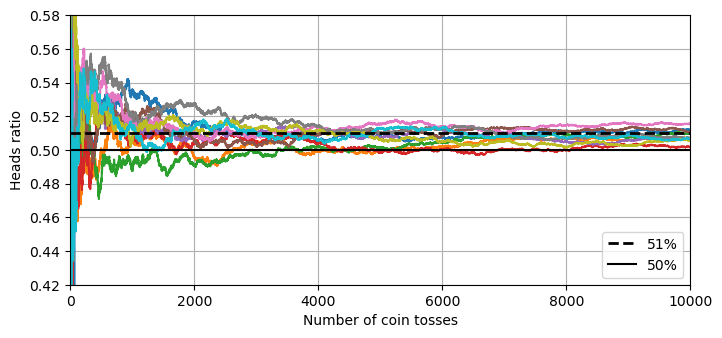

In [2]:
# extra code – this cell generates Figure 6–3

import matplotlib.pyplot as plt
import numpy as np

heads_proba = 0.51
rng = np.random.default_rng(seed=42)
coin_tosses = (rng.random((10000, 10)) < heads_proba).astype(np.int32)
cumulative_heads = coin_tosses.cumsum(axis=0)
cumulative_heads_ratio = cumulative_heads / np.arange(1, 10001).reshape(-1, 1)

plt.figure(figsize=(8, 3.5))
plt.plot(cumulative_heads_ratio)
plt.plot([0, 10000], [0.51, 0.51], "k--", linewidth=2, label="51%")
plt.plot([0, 10000], [0.5, 0.5], "k-", label="50%")
plt.xlabel("Number of coin tosses")
plt.ylabel("Heads ratio")
plt.legend(loc="lower right")
plt.axis([0, 10000, 0.42, 0.58])
plt.grid()

plt.show()

In [3]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

voting_clf = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(random_state=42)),
        ("rf", RandomForestClassifier(random_state=42)),
        ("svc", SVC(random_state=42)),
    ],
)

voting_clf.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [4]:
for name, clf in voting_clf.named_estimators_.items():
    y_pred = clf.predict(X_test)
    print(f"{name} accuracy: {accuracy_score(y_test, y_pred):.2f}")

lr accuracy: 0.86
rf accuracy: 0.90
svc accuracy: 0.90


In [5]:
voting_clf.predict(X_test[:1])

array([1])

In [6]:
[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

[array([1]), array([1]), array([0])]

In [7]:
voting_clf.score(X_test, y_test)

0.912

## Distinsión entre hard voting y soft voting

Hard voting se basa en la mayoría de votos de los clasificadores individuales, mientras que soft voting promedia las probabilidades predichas por cada clasificador y elige la clase con la mayor probabilidad promedio.

Por otro lado soft voting suele ser más efectivo que hard voting, especialmente cuando los clasificadores individuales son bien calibrados y producen probabilidades confiables. Esto se debe a que soft voting tiene en cuenta la confianza de cada clasificador en sus predicciones, lo que puede mejorar la precisión del modelo final.


In [8]:
voting_clf.voting = "soft"
voting_clf.set_params(voting="soft", svc__probability=True)
voting_clf.fit(X_train, y_train)
voting_clf.score(X_test, y_test)

0.92

In [9]:
from sklearn.calibration import CalibratedClassifierCV

# 1. Definimos los modelos base
lr_clf = LogisticRegression(random_state=42)
rf_clf = RandomForestClassifier(random_state=42)
svc_clf = SVC(random_state=42) # Nota: Aquí no necesitas probability=True si usas Calibrated

# 2. Calibramos los que lo necesiten (SVC y RF suelen mejorar mucho)
# CalibratedClassifierCV entrena el modelo internamente usando validación cruzada
calibrated_svc = CalibratedClassifierCV(svc_clf, cv=5)
calibrated_rf = CalibratedClassifierCV(rf_clf, cv=5)
calibrated_lr = CalibratedClassifierCV(lr_clf, cv=5)  # Aunque LR suele estar bien calibrado, lo incluimos para comparar

# 3. Metemos los modelos (calibrados y no calibrados) al VotingClassifier
voting_clf = VotingClassifier(
    estimators=[
        ("lr", calibrated_lr),           # LogisticRegression ya suele estar bien calibrada
        ("rf", calibrated_rf),    # RF calibrado
        ("svc", calibrated_svc),  # SVC calibrado
    ],
)

voting_clf.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [10]:
for name, clf in voting_clf.named_estimators_.items():
    y_pred = clf.predict(X_test)
    print(f"{name} accuracy: {accuracy_score(y_test, y_pred):.4f}")

lr accuracy: 0.8560
rf accuracy: 0.9120
svc accuracy: 0.9040


In [11]:
voting_clf.predict(X_test[:1])

array([0])

In [12]:
[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

[array([0]), array([1]), array([0])]

In [13]:
voting_clf.score(X_test, y_test)

0.92

In [14]:
voting_clf.named_estimators_

{'lr': CalibratedClassifierCV(cv=5, estimator=LogisticRegression(random_state=42)),
 'rf': CalibratedClassifierCV(cv=5, estimator=RandomForestClassifier(random_state=42)),
 'svc': CalibratedClassifierCV(cv=5, estimator=SVC(random_state=42))}

In [15]:
voting_clf.voting = "soft"
voting_clf.set_params(voting="soft", svc__estimator__probability=True)
voting_clf.fit(X_train, y_train)
voting_clf.score(X_test, y_test)

0.912

# Bagging and Pasting
## Bagging and Pasting in Scikit-Learn

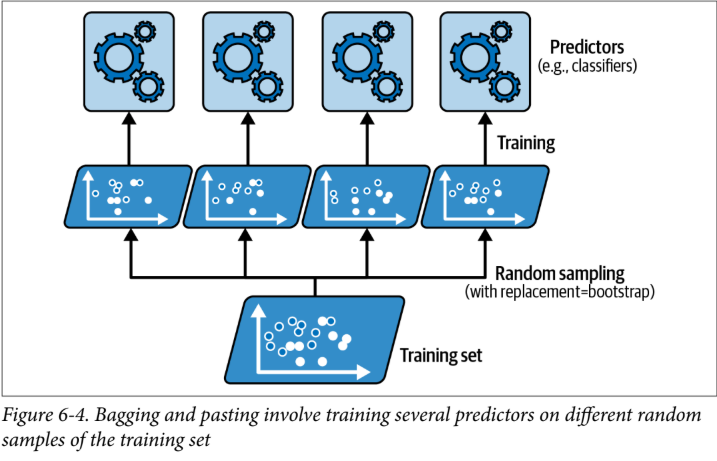

Esta tecnica implica:

1. **Bootstrap Sampling**: Se generan múltiples conjuntos de datos de entrenamiento a partir del conjunto de datos original mediante muestreo con reemplazo (bootstrap sampling). Esto significa que algunos ejemplos pueden aparecer varias veces en un conjunto de entrenamiento, mientras que otros pueden no aparecer en absoluto.

2. **Entrenamiento de Modelos**: Se entrena un modelo independiente en cada uno de los conjuntos de entrenamiento generados. Estos modelos pueden ser del mismo tipo (por ejemplo, todos árboles de decisión) o de tipos diferentes.

3. **Agregación de Predicciones**: Para hacer una predicción final, se agregan las predicciones de todos los modelos individuales. En problemas de clasificación, esto generalmente se hace mediante votación (hard voting o soft voting), mientras que en problemas de regresión se promedian las predicciones.

Pasting es similar a bagging, pero sin reemplazo. En pasting, cada modelo se entrena con un subconjunto diferente del conjunto de datos original, sin permitir que los mismos ejemplos se repitan en diferentes conjuntos de entrenamiento. Esto puede ser útil para reducir la varianza del modelo, aunque generalmente no es tan efectivo como el bagging para mejorar la precisión.

In [16]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            max_samples=100, n_jobs=-1, random_state=42)

bag_clf.fit(X_train, y_train)


,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",500
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",100
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


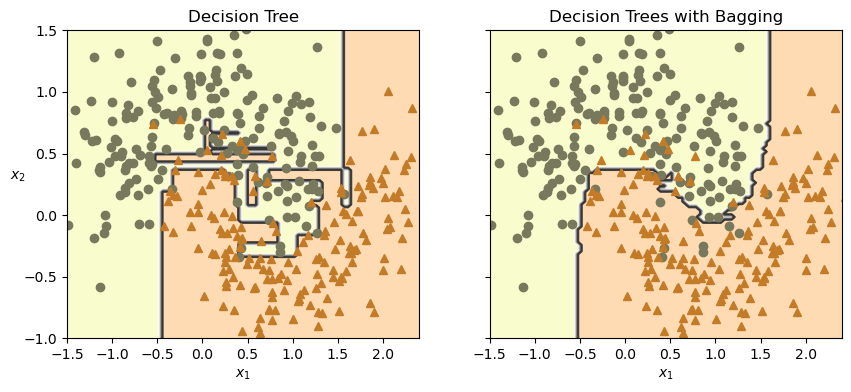

In [17]:
# extra code – this cell generates Figure 6–5

def plot_decision_boundary(clf, X, y, alpha=1.0):
    axes=[-1.5, 2.4, -1, 1.5]
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)

    plt.contourf(x1, x2, y_pred, alpha=0.3 * alpha, cmap='Wistia')
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8 * alpha)
    colors = ["#78785c", "#c47b27"]
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf, X_train, y_train)
plt.title("Decision Tree")
plt.sca(axes[1])
plot_decision_boundary(bag_clf, X_train, y_train)
plt.title("Decision Trees with Bagging")
plt.ylabel("")

plt.show()

## Out-of-Bag Evaluation

El **OOB Evaluation** es una técnica exclusiva de los modelos basados en Bagging que permite evaluar el modelo utilizando los datos sobrantes del proceso de muestreo.

* **La Regla 63/37:** En promedio, cada predictor entrena con el 63% de las instancias. El 37% restante (Out-of-Bag) actúa como un conjunto de prueba natural.
* **Sin desperdicio de datos:** Permite entrenar con todo el dataset y aun así tener una validación confiable sin necesidad de un `X_val` separado.
* **Implementación en Scikit-Learn:** * Se activa con `oob_score=True`.
    * El resultado se consulta en el atributo `oob_score_`.
* **Interpretación:** Si tu `oob_score_` es 0.89, es muy probable que tu precisión en el conjunto de prueba real sea muy cercana a 0.89.

In [18]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                            oob_score=True, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_

0.896

In [19]:
from sklearn.metrics import accuracy_score
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.92

In [20]:
bag_clf.oob_decision_function_[:3] # probas for the first 3 instances

array([[0.32352941, 0.67647059],
       [0.3375    , 0.6625    ],
       [1.        , 0.        ]])

## Random Forests

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16,
                                random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

Los bosques por defecto introduce algo de aleatoriedad en selección de features, que es $\sqrt{d}$, donde $d$ es el número total de características. Esto ayuda a reducir la correlación entre los árboles individuales, lo que a su vez mejora la precisión del modelo final.

In [22]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(max_features="sqrt", max_leaf_nodes=16),
    n_estimators=500, n_jobs=-1, random_state=42)

## Extra-Trees

1. **Umbrales Aleatorios**: A diferencia de Random Forest (RF), que busca el umbral óptimo (split) para cada característica, Extra-Trees elige umbrales **al azar** y se queda con el mejor de esos resultados aleatorios[cite: 1].
2. **Sin Bootstrapping**: Por defecto, utiliza el dataset completo (`bootstrap=False`), lo que reduce el sesgo que introduce el muestreo con reemplazo[cite: 1].
3. **Trade-off de Error**: 
   - **↑ Sesgo (Bias)**: Al no optimizar el umbral, el error sistemático sube ligeramente.
   - **↓ Varianza (Variance)**: La aleatoriedad extrema suaviza el sobreajuste (*overfitting*).
4. **Eficiencia**: Es mucho más rápido de entrenar porque elimina el costo computacional de buscar el "umbral perfecto" en cada nodo[cite: 1].

In [23]:
from sklearn.ensemble import ExtraTreesClassifier

extra_clf = ExtraTreesClassifier(n_estimators=500, max_leaf_nodes=16,
                                 bootstrap=False, random_state=42, n_jobs=-1)

extra_clf.fit(X_train, y_train)
y_pred_extra = extra_clf.predict(X_test)
accuracy_score(y_test, y_pred_extra)

0.912

## Feature Importance

In [24]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf.fit(iris.data, iris.target)
for score, name in sorted(zip(rnd_clf.feature_importances_, iris.feature_names), reverse=True):
    print(f"{name}: {score:.4f}")


petal length (cm): 0.4410
petal width (cm): 0.4234
sepal length (cm): 0.1125
sepal width (cm): 0.0231


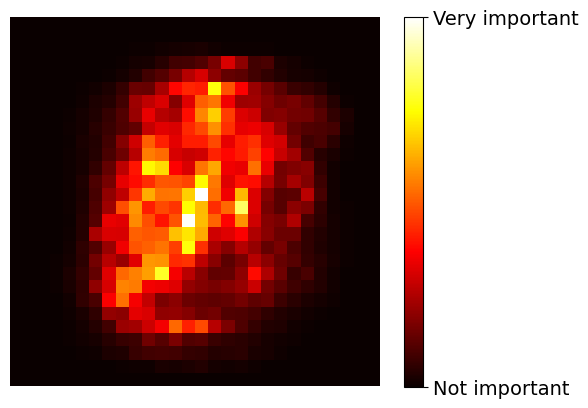

In [25]:
# extra code – this cell generates Figure 6–6

from sklearn.datasets import fetch_openml

X_mnist, y_mnist = fetch_openml('mnist_784', return_X_y=True, as_frame=False,
                                parser='auto')

rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rnd_clf.fit(X_mnist, y_mnist)

heatmap_image = rnd_clf.feature_importances_.reshape(28, 28)
plt.imshow(heatmap_image, cmap="hot")
cbar = plt.colorbar(ticks=[rnd_clf.feature_importances_.min(),
                           rnd_clf.feature_importances_.max()])
cbar.ax.set_yticklabels(['Not important', 'Very important'], fontsize=14)
plt.axis("off")

plt.show()

## Boosting
### AdaBoost

Primero hace un arbol base y luego se enfoca en los errores que cometió ese arbol, asignando más peso a las instancias mal clasificadas. Luego, se entrena un nuevo árbol que intenta corregir esos errores, y así sucesivamente. Al final, se combinan las predicciones de todos los árboles, dando más peso a aquellos que tuvieron un mejor desempeño.

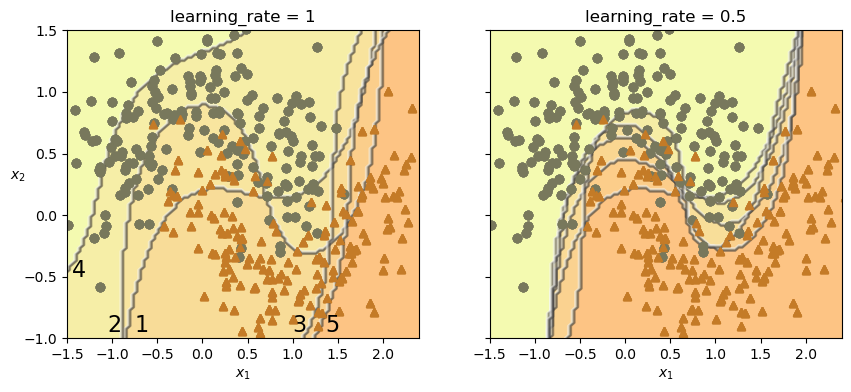

In [26]:
# extra code – this cell generates Figure 6–8

m = len(X_train)  # number of instances

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
for subplot, learning_rate in ((0, 1), (1, 0.5)):
    sample_weights = np.ones(m) / m
    plt.sca(axes[subplot])
    for i in range(5):
        svm_clf = SVC(C=0.2, gamma=0.6, random_state=42)
        svm_clf.fit(X_train, y_train, sample_weight=sample_weights * m)
        y_pred = svm_clf.predict(X_train)

        error_weights = sample_weights[y_pred != y_train].sum()
        r = error_weights / sample_weights.sum()  # equation 7-1
        alpha = learning_rate * np.log((1 - r) / r)  # equation 7-2
        sample_weights[y_pred != y_train] *= np.exp(alpha)  # equation 7-3
        sample_weights /= sample_weights.sum()  # normalization step

        plot_decision_boundary(svm_clf, X_train, y_train, alpha=0.4)
        plt.title(f"learning_rate = {learning_rate}")
    if subplot == 0:
        plt.text(-0.75, -0.95, "1", fontsize=16)
        plt.text(-1.05, -0.95, "2", fontsize=16)
        plt.text(1.0, -0.95, "3", fontsize=16)
        plt.text(-1.45, -0.5, "4", fontsize=16)
        plt.text(1.36,  -0.95, "5", fontsize=16)
    else:
        plt.ylabel("")

plt.show()

AdaBoost entrena predictores de forma secuencial, donde cada nuevo modelo se enfoca en corregir los errores de los anteriores mediante la actualización de pesos de las instancias.

---

#### 1️⃣ Tasa de error ponderada del predictor ($r_j$)
Para el $j$-ésimo predictor, se calcula su tasa de error ponderada sobre el conjunto de entrenamiento:
$$r_j = \frac{\sum_{i=1, \hat{y}_j^{(i)} \neq y^{(i)}}^m w^{(i)}}{\sum_{i=1}^m w^{(i)}}$$
*Donde $\hat{y}_j^{(i)}$ es la predicción del predictor para la instancia $i$.*

#### 2️⃣ Peso del predictor ($\alpha_j$)
Calcula la importancia o "poder de voto" del modelo en el ensamble. A mayor precisión, mayor peso:
$$\alpha_j = \eta \log \frac{1 - r_j}{r_j}$$
*   **$\eta$**: Tasa de aprendizaje (hiperparámetro, por defecto 1).
*   Si $r_j$ es pequeño (buen modelo), $\alpha_j$ es alto y positivo.
*   Si $r_j = 0.5$ (azar), $\alpha_j$ es cero.

#### 3️⃣ Regla de actualización de pesos ($w^{(i)}$)
Se aumentan los pesos de las instancias mal clasificadas para que el siguiente modelo les preste más atención:
$$w^{(i)} \leftarrow \begin{cases} w^{(i)} & \text{si } \hat{y}_j^{(i)} = y^{(i)} \\ w^{(i)} \exp(\alpha_j) & \text{si } \hat{y}_j^{(i)} \neq y^{(i)} \end{cases}$$
*Tras la actualización, los pesos se normalizan para que su suma sea igual a 1[cite: 1].*

#### 4️⃣ Predicción final del ensamble
La clase predicha es la que obtiene la mayoría de los votos ponderados de todos los predictores ($N$):
$$\hat{y}(x) = \text{argmax}_k \sum_{j=1, \hat{y}_j(x) = k}^N \alpha_j$$

In [35]:
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators=30,
    learning_rate=0.5, random_state=42)
ada_clf.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",30
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


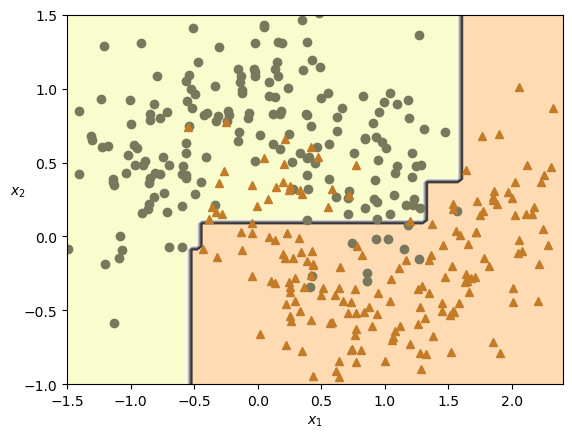

In [36]:
plot_decision_boundary(ada_clf, X_train, y_train)